# Does Borrower Free Text Carry Credit-Risk Signal?

**The gate question:** before building anything on top of it, does a borrower's
free-text loan description (`desc`) carry default-risk signal beyond what
traditional underwriting fields already capture — or is any apparent lift just
an artifact of *who bothers to write one*?

This notebook is a communication layer over work already completed. It presents
findings recorded in `DECISIONS.md`; it does not re-run any modeling. Descriptive
counts (fill rate, class balance) are recomputed here because they're
deterministic — the same numbers every time, from the same saved data. Every
PR-AUC, ROC-AUC, and delta is read from `results/feasibility_metrics.json`,
which transcribes the logged findings verbatim.

**Why the 2007–2013 window.** LendingClub collected the `desc` field only in
its early years and phased it out entirely by 2015. Any test of the text
channel is only possible where usable text and a resolved loan outcome
(Fully Paid / Charged Off) coexist — which, as the audit below shows, is
2007–2013 and nowhere else.

## 1. Data audit — does usable text even exist?

Recomputed directly from `data/interim/subset_cache.pkl` (the full column-limited
loan subset, all vintages). For each issue year: the fill rate of non-empty
`desc` (whitespace-stripped), and how that rate decays over time.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "font.size": 11,
})

ROOT = Path("..").resolve()
BAR_COLOR = "#3b6ea5"
ACCENT_COLOR = "#c0453a"


In [2]:
subset = pd.read_pickle(ROOT / "data" / "interim" / "subset_cache.pkl")

if "issue_year" not in subset.columns:
    subset["issue_year"] = pd.to_datetime(
        subset["issue_d"], format="%b-%Y", errors="coerce"
    ).dt.year

desc_stripped = subset["desc"].str.strip()
subset["_desc_nonempty"] = desc_stripped.notna() & (desc_stripped != "")

fill_by_year = (
    subset.groupby("issue_year")["_desc_nonempty"]
    .agg(total="size", nonempty="sum")
    .assign(pct_filled=lambda d: 100 * d["nonempty"] / d["total"])
    .loc[2007:2015]
)
fill_by_year

,total,nonempty,pct_filled
issue_year,,,
2007.0,603,588,97.512438
2008.0,2393,2393,100.0
2009.0,5281,5025,95.152433
2010.0,12537,8286,66.092367
2011.0,21721,12723,58.574651
2012.0,53367,32743,61.354395
2013.0,134814,48730,36.146098
2014.0,235629,15274,6.482224
2015.0,421095,33,0.007837


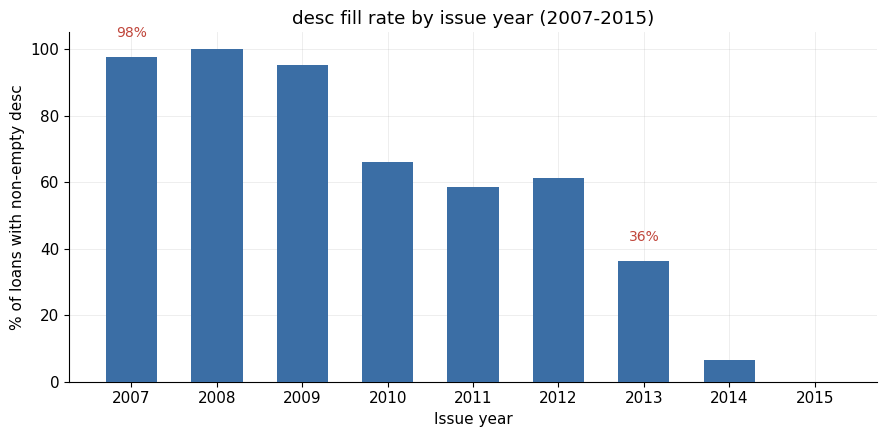

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
years = fill_by_year.index.astype(int)
ax.bar(years, fill_by_year["pct_filled"], color=BAR_COLOR, width=0.6, zorder=3)

ax.set_title("desc fill rate by issue year (2007-2015)")
ax.set_xlabel("Issue year")
ax.set_ylabel("% of loans with non-empty desc")
ax.set_ylim(0, 105)
ax.set_xticks(years)

first_pct = fill_by_year.loc[2007, "pct_filled"]
last_pct = fill_by_year.loc[2013, "pct_filled"]
ax.annotate(
    f"{first_pct:.0f}%",
    xy=(2007, first_pct), xytext=(2007, first_pct + 6),
    ha="center", fontsize=10, color=ACCENT_COLOR,
)
ax.annotate(
    f"{last_pct:.0f}%",
    xy=(2013, last_pct), xytext=(2013, last_pct + 6),
    ha="center", fontsize=10, color=ACCENT_COLOR,
)

fig.tight_layout()
plt.show()

**The collapse:** fill rate opens near-universal (97–100% in 2007–2008), stays
usable through 2012, then drops sharply — 36% by 2013, single digits by 2014,
and essentially zero from 2015 on, when LendingClub stopped collecting the
field. This is why the analysis window is locked to 2007–2013: it's the only
range where text is common enough to test and loans have had time to resolve.

## 2. Class balance — full resolved population vs. the desc-only subset

Restricting to loans with non-empty `desc` shrinks the population to those who
chose to write one. Recomputed here (deterministic counts) to check whether
that restriction itself skews the default rate — a first, coarse look at
selection bias, ahead of the formal has_desc control in Section 3.

In [4]:
feasibility = pd.read_pickle(ROOT / "data" / "interim" / "feasibility_frame.pkl")

mask_years = subset["issue_year"].between(2007, 2013)
mask_status = subset["loan_status"].isin(["Fully Paid", "Charged Off"])
full_resolved = subset.loc[mask_years & mask_status]

full_balance = full_resolved["loan_status"].value_counts(normalize=True).mul(100)
desc_balance = feasibility["default"].map({0: "Fully Paid", 1: "Charged Off"}) \
    .value_counts(normalize=True).mul(100)

balance_df = pd.DataFrame({
    "Full resolved (n={:,})".format(len(full_resolved)): full_balance,
    "Desc-only (n={:,})".format(len(feasibility)): desc_balance,
}).loc[["Fully Paid", "Charged Off"]]
balance_df

,"Full resolved (n=227,957)","Desc-only (n=108,076)"
Fully Paid,84.497954,84.737592
Charged Off,15.502046,15.262408


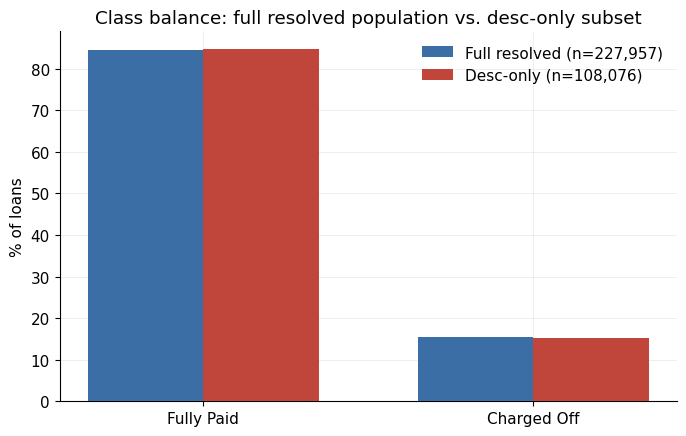

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
labels = ["Fully Paid", "Charged Off"]
x = range(len(labels))
width = 0.35

ax.bar([i - width / 2 for i in x], balance_df.iloc[:, 0], width,
       label=balance_df.columns[0], color=BAR_COLOR, zorder=3)
ax.bar([i + width / 2 for i in x], balance_df.iloc[:, 1], width,
       label=balance_df.columns[1], color=ACCENT_COLOR, zorder=3)

ax.set_title("Class balance: full resolved population vs. desc-only subset")
ax.set_ylabel("% of loans")
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.legend(frameon=False, loc="upper right")

fig.tight_layout()
plt.show()

Class balance barely moves between the two populations (~84.5/15.5 vs.
~84.7/15.3). On its own this is weak evidence against selection bias — it only
rules out a *marginal* shift. It says nothing about a *conditional* selection
effect once grade, rate, and the other underwriting fields are already in the
model. That's what the has_desc control in the next section is for.

## 3. Baseline and controls — the modeling ladder

Four models, read from `results/feasibility_metrics.json` (no retraining here):

- **A** — 13 tabular features only (the origination-time baseline).
- **A+len** — A plus the word count of the cleaned description (verbosity control).
- **B-full** — A plus a binary `has_desc` flag, trained on the *full* 227,957-row
  resolved population (has_desc is constant on the desc-only subset, so this
  control necessarily runs on a different, larger population than A/A+len/C).
- **C** — A plus TF-IDF over the cleaned description text (the content model).

A, A+len, and C share the identical 108,076-row desc-only population and split;
B-full does not — it's included to show where the *presence* bar sits relative
to the *content* ladder, not for a row-for-row comparison.

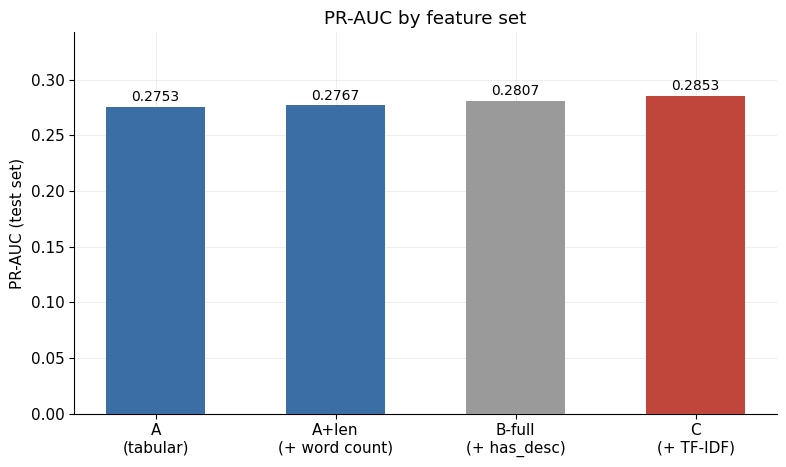

In [6]:
with open(ROOT / "results" / "feasibility_metrics.json") as f:
    metrics = json.load(f)

model_a = metrics["finding2_model_a"]
sel = metrics["finding3_selection_bias"]
lift = metrics["finding4_text_lift"]

bar_labels = ["A\n(tabular)", "A+len\n(+ word count)", "B-full\n(+ has_desc)", "C\n(+ TF-IDF)"]
bar_values = [
    lift["models"]["A"]["pr_auc_mean"],
    lift["models"]["A+len"]["pr_auc_mean"],
    sel["b_full"]["pr_auc"],
    lift["models"]["C"]["pr_auc_mean"],
]
bar_colors = [BAR_COLOR, BAR_COLOR, "#9a9a9a", ACCENT_COLOR]

fig, ax = plt.subplots(figsize=(8, 4.8))
bars = ax.bar(bar_labels, bar_values, color=bar_colors, width=0.55, zorder=3)
for rect, val in zip(bars, bar_values):
    ax.annotate(f"{val:.4f}", xy=(rect.get_x() + rect.get_width() / 2, val),
                xytext=(0, 4), textcoords="offset points", ha="center", fontsize=10)

ax.set_title("PR-AUC by feature set")
ax.set_ylabel("PR-AUC (test set)")
ax.set_ylim(0, max(bar_values) * 1.2)

fig.tight_layout()
plt.show()

**Reading the ladder:** A and A+len are close together — verbosity alone buys
almost nothing. B-full (gray) sits on a different, larger population and is
included as the presence-only reference point, not a fifth rung on the same
ladder — it will reappear as the flat "selection bar" in the next chart. C is
the only model that visibly separates from the tabular baseline.

## 4. Is the lift real, or one lucky split?

Three deltas, each computed on the identical desc-only population across three
random seeds (42, 43, 44; seed 42 reuses Model A's exact locked split). Error
bars are ±1 standard deviation across seeds. The dashed reference line is the
has_desc selection bar from Section 3's B-full model (Finding 3): essentially
flat, at −0.0002.

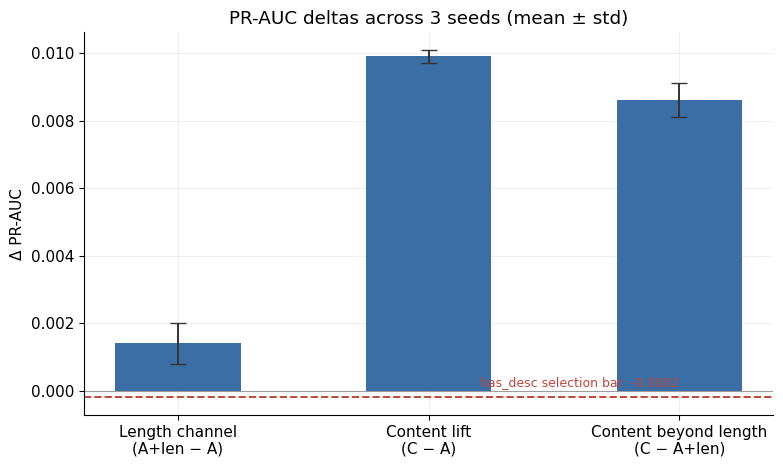

In [7]:
deltas = lift["deltas_pr_auc"]
delta_names = ["Length channel\n(A+len − A)", "Content lift\n(C − A)", "Content beyond length\n(C − A+len)"]
delta_keys = ["length_channel_Alen_minus_A", "content_lift_C_minus_A", "content_beyond_length_C_minus_Alen"]
delta_means = [deltas[k]["mean"] for k in delta_keys]
delta_stds = [deltas[k]["std"] for k in delta_keys]
selection_bar = lift["has_desc_selection_bar_pr_auc"]

fig, ax = plt.subplots(figsize=(8, 4.8))
x = range(len(delta_names))
ax.bar(x, delta_means, yerr=delta_stds, capsize=6, color=BAR_COLOR, width=0.5,
       zorder=3, error_kw={"elinewidth": 1.4, "ecolor": "#333333"})

ax.axhline(selection_bar, color=ACCENT_COLOR, linestyle="--", linewidth=1.4, zorder=2)
ax.annotate(f"has_desc selection bar: {selection_bar:+.4f}",
            xy=(len(delta_names) - 1, selection_bar), xytext=(0, 8),
            textcoords="offset points", ha="right", color=ACCENT_COLOR, fontsize=9)

ax.set_title("PR-AUC deltas across 3 seeds (mean \u00b1 std)")
ax.set_ylabel("\u0394 PR-AUC")
ax.set_xticks(list(x))
ax.set_xticklabels(delta_names)
ax.axhline(0, color="#999999", linewidth=0.8, zorder=1)

fig.tight_layout()
plt.show()

Both the content-lift and content-beyond-length deltas are positive with tight
error bars, and stayed positive in all three individual seed runs. The has_desc
selection bar sits at essentially zero — the mere presence of a description
carries no standalone signal once tabular features are already in the model.
The content of the text does.

## 5. What is the model actually picking up on?

The top 20 TF-IDF features by gain in model C (seed 42), read from
`results/feasibility_metrics.json`. This is the audit that decides whether the
lift is genuine language or an artifact of the template-stripping step: any
leftover `borrower` / `added` / `br` / date fragments here would mean the
"content" signal was actually leftover formatting, not text.

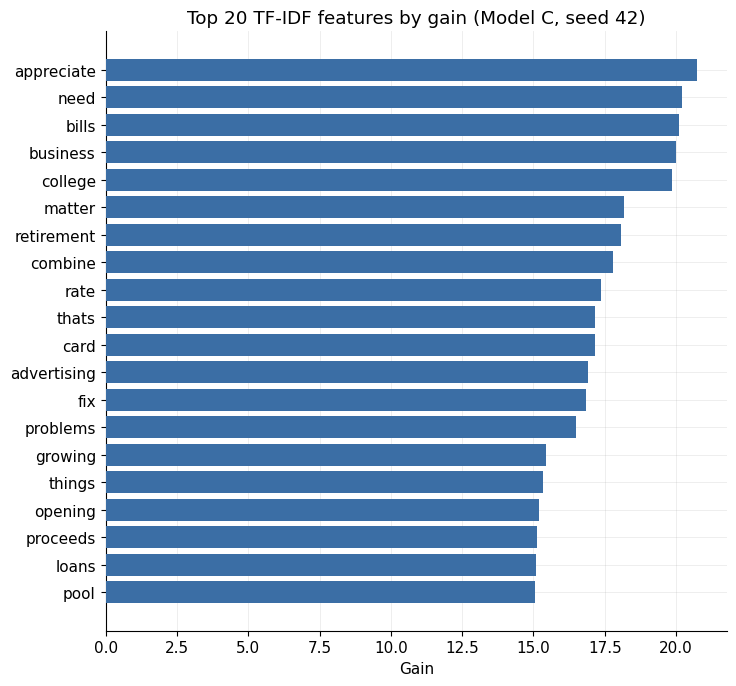

In [8]:
top20 = lift["top20_tfidf_gain_seed42"]
words = [w for w, _ in top20][::-1]
gains = [g for _, g in top20][::-1]

fig, ax = plt.subplots(figsize=(7.5, 7))
ax.barh(words, gains, color=BAR_COLOR, zorder=3)
ax.set_title("Top 20 TF-IDF features by gain (Model C, seed 42)")
ax.set_xlabel("Gain")

fig.tight_layout()
plt.show()

No template residue: no `borrower`, `added`, `br`, or date-like tokens. The
list reads as genuine borrower language — purpose framing (`bills`, `business`,
`college`, `retirement`, `combine`, `card`, `loans`), tone (`appreciate`,
`matter`, `thats`), and financial-stress vocabulary (`fix`, `problems`,
`growing`). Several terms are purpose-adjacent even though `purpose` is already
a tabular column — meaning the lift is discrimination *within* a stated
purpose, not a restatement of it.

## Verdict: PASS — stated honestly

The content of borrower free text carries genuine incremental default-risk
signal beyond tabular underwriting fields, beyond the mere presence of a
description, and beyond its length. The lift is positive across all three
seeds, survives both selection controls, and the features driving it read as
real language rather than leftover template formatting or a restatement of
fields the model already has.

**What this is not:**

- **Modest, not large.** The content lift is +0.0099 PR-AUC over the tabular
  baseline — roughly a 3.6% relative improvement. This is a real, defensible
  signal, not a transformative one. Whether it moves enough real decisions to
  matter in practice is a separate, open question.
- **Within-purpose, not purpose-replacing.** Much of the vocabulary is
  purpose-adjacent, but `purpose` is already a tabular feature. The gain
  measures use, not direction — this notebook does not claim to know *which
  way* any given word pushes risk, only that the text carries information the
  structured fields don't.
- **Built on an extinct input.** This entire result lives on the 2007–2013
  vintages, where 47% of resolved loans have a non-empty `desc`. LendingClub
  stopped collecting the field industry-wide by 2015. The finding is real and
  historically grounded, but it is not deployable against current loan
  applications — the column it depends on no longer exists. This is a methods
  demonstration on a historical corpus, not a live underwriting signal.